# Task 1 — Gridworld RL (Random_Switch + Custom Varying Maze)

This notebook contains a complete, **non-cheating** solution scaffold for Task 1:

- **Random_Switch**: Dyna-Q with time-augmented state `(obs, t mod 5)` + optional safety filters.
- **Plot**: mean true episode return over episodes, averaged over **100 environments**.
- **Custom environment**: a **varying maze** derived from `GridworldEnv`, solvable **by construction** (no BFS/DFS).

**Rules respected**: no edits to provided files, no `step_dp`, no algorithmic path-search.


## Attribution / External assistance

I used ChatGPT (OpenAI) as a coding assistant for brainstorming and scaffolding (e.g., Dyna-Q structure, plotting helpers, and experiment runner). I then implemented, tested, debugged, and tuned the final code myself, and verified that it follows the assignment rules (no `step_dp`, no path-search).


## 0) Setup
Put this notebook in the same folder as `gridworld.py` and `config.py`.

If imports fail, adjust the `sys.path` line in the next cell.


In [1]:
import os, sys, random
from dataclasses import dataclass
from typing import Dict, Tuple, List, Optional

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

# If gridworld.py and config.py are not in the current folder, add their folder:
# sys.path.append(r"PATH/TO/FOLDER")

from gridworld import GridworldEnv, Random_Switch
from config import G_UP, G_RIGHT, G_DOWN, G_LEFT, G_STAY

print("Working directory:", os.getcwd())


Working directory: f:\Desktop\MAI - 3\DRL\Task 1\Task_1_Umang_dholakiya


## 1) Utilities (seeding, smoothing, auto-zoom)

Auto-zoom chooses an episode range around the learning transition.

In [2]:
Action = int
StateIdx = int
ModelValue = Tuple[StateIdx, float, bool]


def set_global_seeds(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)


def moving_average(x: np.ndarray, window: int) -> np.ndarray:
    if window <= 1:
        return x.astype(np.float64, copy=True)
    window = min(window, len(x))
    kernel = np.ones(window, dtype=np.float64) / window
    return np.convolve(x, kernel, mode="same")


def auto_zoom_range(mean_r: np.ndarray, *, smooth_window: int = 25, min_width: int = 200) -> Tuple[int, int]:
    """Return (start_idx, end_idx) slice focusing on the learning transition."""
    n = len(mean_r)
    if n < 50:
        return 0, n

    smooth = moving_average(mean_r, smooth_window)
    tail = smooth[-min(100, max(20, n // 10)):]
    plateau = float(np.mean(tail))

    low_thr = plateau - 40.0
    high_thr = plateau - 5.0

    start = None
    end = None
    for i in range(n):
        if start is None and smooth[i] >= low_thr:
            start = i
        if start is not None and smooth[i] >= high_thr:
            end = i
            break

    if start is None:
        start = 0
    if end is None:
        end = n - 1

    s = max(0, start - 50)
    e = min(n, end + 50)

    if e - s < min_width:
        center = (s + e) // 2
        s = max(0, center - min_width // 2)
        e = min(n, s + min_width)
        s = max(0, e - min_width)

    return s, e

# Reference (LLM assistance): ChatGPT (OpenAI) suggested scaffolding for this Dyna-Q planning loop; 


## 2) Random_Switch helper functions
Random_Switch has special behavior every 5th step. We can filter actions on those steps to avoid parity-based instant death.

In [3]:
def obs_to_xy(obs: int, n_cols: int) -> Tuple[int, int]:
    return obs // n_cols, obs % n_cols


def predict_switch_next_xy(x: int, y: int, action: Action, m: int, n: int) -> Tuple[int, int]:
    # Switch step: ignore obstacles, only boundary clip
    if action == G_LEFT:
        x_n, y_n = x, y - 1
    elif action == G_UP:
        x_n, y_n = x - 1, y
    elif action == G_RIGHT:
        x_n, y_n = x, y + 1
    elif action == G_DOWN:
        x_n, y_n = x + 1, y
    elif action == G_STAY:
        x_n, y_n = x, y
    else:
        raise ValueError(f"Unknown action: {action}")

    x_n = min(max(x_n, 0), m - 1)
    y_n = min(max(y_n, 0), n - 1)
    return x_n, y_n


def allowed_actions_switch_safety(env: GridworldEnv, obs: int) -> List[Action]:
    """Prefer actions that land on odd parity on the next switch step."""
    m, n = env.shape()
    x, y = obs_to_xy(obs, n)
    safe: List[Action] = []
    for a in range(env.num_actions()):
        x_n, y_n = predict_switch_next_xy(x, y, a, m, n)
        if (x_n + y_n) % 2 == 1:
            safe.append(a)
    return safe if safe else list(range(env.num_actions()))


## 3) Dyna-Q Agent (tabular)

Important: we augment state with `t mod 5` so Random_Switch becomes Markov.

Optional `avoid_fatal`: avoid actions that the learned model has already observed to lead to terminal `-100`.

In [4]:
@dataclass
class EpsilonSchedule:
    eps_start: float = 1.0
    eps_end: float = 0.01
    eps_decay: float = 0.992

    def value(self, episode_idx: int) -> float:
        eps = self.eps_end + (self.eps_start - self.eps_end) * (self.eps_decay ** episode_idx)
        return float(max(self.eps_end, min(self.eps_start, eps)))


class DynaQAgent:
    def __init__(
        self,
        n_states: int,
        n_actions: int,
        alpha: float = 0.12,
        gamma: float = 0.99,
        planning_steps: int = 100,
        q_init: float = 2.0,
        rng_seed: int = 0,
    ) -> None:
        self.n_states = int(n_states)
        self.n_actions = int(n_actions)
        self.alpha = float(alpha)
        self.gamma = float(gamma)
        self.planning_steps = int(planning_steps)

        self.Q = np.full((self.n_states, self.n_actions), float(q_init), dtype=np.float64)
        self.model: Dict[Tuple[StateIdx, Action], ModelValue] = {}
        self._model_keys: List[Tuple[StateIdx, Action]] = []
        self.rng = np.random.default_rng(rng_seed)

    def _q_update(self, s: StateIdx, a: Action, r: float, s_next: StateIdx, done: bool) -> None:
        target = r if done else (r + self.gamma * float(np.max(self.Q[s_next])))
        self.Q[s, a] += self.alpha * (target - self.Q[s, a])

    def observe(self, s: StateIdx, a: Action, r: float, s_next: StateIdx, done: bool) -> None:
        key = (s, a)
        if key not in self.model:
            self._model_keys.append(key)
        self.model[key] = (s_next, float(r), bool(done))
        self._q_update(s, a, r, s_next, done)

    def plan(self) -> None:
        if not self._model_keys or self.planning_steps <= 0:
            return
        for _ in range(self.planning_steps):
            s, a = self._model_keys[self.rng.integers(0, len(self._model_keys))]
            s_next, r, done = self.model[(s, a)]
            self._q_update(s, a, r, s_next, done)

    def greedy_action(self, s: StateIdx, allowed_actions: Optional[List[Action]] = None) -> Action:
        if allowed_actions is None or len(allowed_actions) == self.n_actions:
            q = self.Q[s]
            mx = np.max(q)
            best = np.flatnonzero(np.isclose(q, mx))
            return int(self.rng.choice(best))
        qvals = self.Q[s, allowed_actions]
        mx = np.max(qvals)
        best_idx = np.flatnonzero(np.isclose(qvals, mx))
        return int(allowed_actions[int(self.rng.choice(best_idx))])

    def act(self, s: StateIdx, epsilon: float, *, allowed_actions: Optional[List[Action]] = None) -> Action:
        if allowed_actions is None:
            allowed_actions = list(range(self.n_actions))
        if self.rng.random() < epsilon:
            return int(allowed_actions[self.rng.integers(0, len(allowed_actions))])
        return self.greedy_action(s, allowed_actions)


def encode_state(obs: int, t_mod: int, n_obs_states: int) -> int:
    return int(t_mod) * int(n_obs_states) + int(obs)


def allowed_actions_avoid_fatal(agent: DynaQAgent, s: StateIdx) -> List[Action]:
    allowed: List[Action] = []
    for a in range(agent.n_actions):
        mv = agent.model.get((s, a))
        if mv is None:
            allowed.append(a)
            continue
        _, r, done = mv
        if not (done and float(r) <= -100.0):
            allowed.append(a)
    return allowed if allowed else list(range(agent.n_actions))

# Reference (LLM assistance): ChatGPT (OpenAI) suggested scaffolding for this Dyna-Q planning loop; 



## 4) Custom varying maze environment

Varying maze derived from `GridworldEnv`, solvable by construction (no BFS/DFS).

In [5]:
class VaryingMazeEnv(GridworldEnv):
    def __init__(
        self,
        size: int = 12,
        branch_count: int = 14,
        branch_len_min: int = 2,
        branch_len_max: int = 7,
        open_p: float = 0.07,
        water_p: float = 0.05,
        seed: int = 0,
    ) -> None:
        self.step_cost = 0
        self.g_reward = 100
        self.o_reward = -100

        rng = np.random.default_rng(seed)
        n = int(size)
        m = int(size)

        start = (0, 0)
        goal = (m - 1, n - 1)

        grid = np.full((m, n), "#", dtype="<U1")

        # Carve monotone corridor by shuffling rights + downs
        corridor = set()
        x, y = start
        corridor.add((x, y))
        grid[x, y] = " "
        moves = ["R"] * (n - 1) + ["D"] * (m - 1)
        rng.shuffle(moves)
        for mv in moves:
            if mv == "R":
                y += 1
            else:
                x += 1
            corridor.add((x, y))
            grid[x, y] = " "

        # Branches (dead-ends) off corridor
        corridor_list = list(corridor)
        dirs = [(0, 1), (1, 0), (0, -1), (-1, 0)]
        for _ in range(int(branch_count)):
            sx, sy = corridor_list[int(rng.integers(0, len(corridor_list)))]
            length = int(rng.integers(branch_len_min, branch_len_max + 1))
            bx, by = sx, sy
            for _ in range(length):
                dx, dy = dirs[int(rng.integers(0, 4))]
                nx, ny = bx + dx, by + dy
                if nx < 0 or nx >= m or ny < 0 or ny >= n:
                    break
                if (nx, ny) in corridor:
                    bx, by = nx, ny
                    continue
                grid[nx, ny] = " "
                bx, by = nx, ny

            # Put water at branch end sometimes (never on corridor)
            if (bx, by) not in corridor and (bx, by) != start and (bx, by) != goal:
                if rng.random() < 0.60:
                    grid[bx, by] = "O"

        # Sprinkle extra open + water away from corridor
        for i in range(m):
            for j in range(n):
                if (i, j) in corridor or (i, j) == start or (i, j) == goal:
                    continue
                if grid[i, j] == "#":
                    if rng.random() < open_p:
                        grid[i, j] = " "
                if grid[i, j] == " " and rng.random() < water_p:
                    grid[i, j] = "O"

        grid[start[0], start[1]] = "S"
        grid[goal[0], goal[1]] = "G"

        self.grid = [list(row) for row in grid.tolist()]
        super().__init__()


In [6]:
# Visualize the VaryingMazeEnv environment
def visualize_varying_maze(env: VaryingMazeEnv):
    for row in env.grid:
        print("".join(row))

# Example usage
example_env = VaryingMazeEnv(size=12, branch_count=14, seed=42)
visualize_varying_maze(example_env)

S#### ######
  ## #######
#     ######
  O  O######
O   O#######
O      ## ##
#### #  # ##
######  ### 
#####O  ##O#
### #      #
##### ##   #
########   G


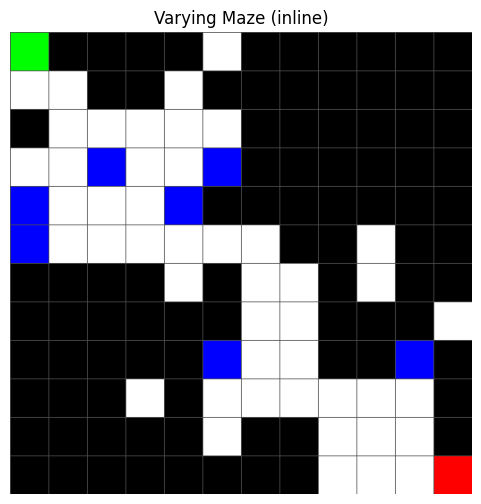

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def visualize_varying_maze_inline(env):
    grid = env.grid
    rows = len(grid)
    cols = len(grid[0])
    scale = 50  # pixel size of each cell

    img = np.zeros((rows * scale, cols * scale, 3), dtype=np.uint8)

    color_map = {
        "#": (0, 0, 0),       # Wall: Black
        " ": (255, 255, 255), # Path: White
        "S": (0, 255, 0),     # Start: Green
        "G": (0, 0, 255),     # Goal: Red
        "O": (255, 0, 0),     # Water: Blue
    }

    for i, row in enumerate(grid):
        for j, cell in enumerate(row):
            color = color_map.get(cell, (128, 128, 128))
            cv2.rectangle(
                img,
                (j * scale, i * scale),
                ((j + 1) * scale, (i + 1) * scale),
                color,
                -1
            )

    # Optional: draw cell grid lines (looks nicer)
    for i in range(rows + 1):
        cv2.line(img, (0, i * scale), (cols * scale, i * scale), (80, 80, 80), 1)
    for j in range(cols + 1):
        cv2.line(img, (j * scale, 0), (j * scale, rows * scale), (80, 80, 80), 1)

    # Convert BGR (OpenCV) -> RGB (matplotlib)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(6, 6))
    plt.imshow(img_rgb)
    plt.axis("off")
    plt.title("Varying Maze (inline)")
    plt.show()

# Example usage
example_env = VaryingMazeEnv(size=12, branch_count=14, seed=42)
visualize_varying_maze_inline(example_env)


## 5) Training loop + experiment runner

In [8]:
def make_env(env_name: str, seed: int) -> GridworldEnv:
    if env_name == "random_switch":
        set_global_seeds(seed)
        return Random_Switch(size=12, water=0.4, mountain=0.0, valid_path_guaranteed=False)
    if env_name == "varying_maze":
        return VaryingMazeEnv(seed=seed)
    raise ValueError(f"Unknown env: {env_name}")


def train_single_env(
    env: GridworldEnv,
    *,
    episodes: int,
    max_steps: int,
    alpha: float,
    gamma: float,
    planning_steps: int,
    q_init: float,
    eps_schedule: EpsilonSchedule,
    rng_seed: int,
    switch_safety: bool,
    avoid_fatal: bool,
) -> np.ndarray:
    n_obs_states = env.num_states()
    n_states_aug = n_obs_states * 5
    n_actions = env.num_actions()

    agent = DynaQAgent(
        n_states=n_states_aug,
        n_actions=n_actions,
        alpha=alpha,
        gamma=gamma,
        planning_steps=planning_steps,
        q_init=q_init,
        rng_seed=rng_seed,
    )

    returns = np.zeros(episodes, dtype=np.float64)

    for ep in range(episodes):
        obs = env.reset()
        total_r = 0.0
        step_in_ep = 0
        eps = eps_schedule.value(ep)

        for _ in range(max_steps):
            s = encode_state(obs, step_in_ep % 5, n_obs_states)

            allowed: Optional[List[Action]] = None
            if avoid_fatal:
                allowed = allowed_actions_avoid_fatal(agent, s)

            if switch_safety and ((step_in_ep + 1) % 5 == 0):
                safe = allowed_actions_switch_safety(env, obs)
                if allowed is None:
                    allowed = safe
                else:
                    allowed_set = set(allowed)
                    allowed = [a for a in safe if a in allowed_set] or safe

            a = agent.act(s, eps, allowed_actions=allowed)
            next_obs, r, done = env.step(a)
            total_r += float(r)

            s_next = encode_state(next_obs, (step_in_ep + 1) % 5, n_obs_states)
            agent.observe(s, a, float(r), s_next, bool(done))
            agent.plan()

            obs = next_obs
            step_in_ep += 1
            if done:
                break

        returns[ep] = total_r

    return returns


def run_experiment(
    *,
    env_name: str,
    num_envs: int,
    episodes: int,
    max_steps: int,
    alpha: float,
    gamma: float,
    planning_steps: int,
    q_init: float,
    eps_start: float,
    eps_end: float,
    eps_decay: float,
    switch_safety: bool,
    avoid_fatal: bool,
    base_seed: int = 0,
) -> Tuple[np.ndarray, np.ndarray]:
    all_returns = np.zeros((num_envs, episodes), dtype=np.float64)
    eps_schedule = EpsilonSchedule(eps_start=eps_start, eps_end=eps_end, eps_decay=eps_decay)

    for i in range(num_envs):
        env_seed = base_seed + i * 1000
        env = make_env(env_name, env_seed)
        agent_seed = env_seed + 12345

        use_switch = switch_safety and (env_name == "random_switch")
        use_avoid = avoid_fatal and (env_name == "random_switch")

        all_returns[i] = train_single_env(
            env,
            episodes=episodes,
            max_steps=max_steps,
            alpha=alpha,
            gamma=gamma,
            planning_steps=planning_steps,
            q_init=q_init,
            eps_schedule=eps_schedule,
            rng_seed=agent_seed,
            switch_safety=use_switch,
            avoid_fatal=use_avoid,
        )

    return all_returns.mean(axis=0), all_returns.std(axis=0)

# Reference (LLM assistance): ChatGPT (OpenAI) suggested scaffolding for this Dyna-Q planning loop; 



## 6) Plotting (full + auto-zoom) + CSV output

In [11]:
def plot_learning_curve(mean_r: np.ndarray, std_r: np.ndarray, *, title: str, out_prefix: str, zoom: bool = True):
    x = np.arange(1, len(mean_r) + 1)

    def _plot(ax, xs, m, s):
        ax.plot(xs, m, label="mean return")
        ax.fill_between(xs, m - s, m + s, alpha=0.2, label="±1 std")
        ax.set_xlabel("Episode")
        ax.set_ylabel("Return (true cumulative reward)")
        ax.set_title(title)
        ax.yaxis.set_major_locator(MultipleLocator(10))
        ax.legend()

    fig, ax = plt.subplots(figsize=(10, 6))
    _plot(ax, x, mean_r, std_r)
    y_min = 10 * np.floor(float(np.min(mean_r - std_r)) / 10.0)
    y_max = 10 * np.ceil(float(np.max(mean_r + std_r)) / 10.0)
    if y_min < y_max:
        ax.set_ylim(y_min, y_max)
    fig.tight_layout()
    fig.savefig(f"{out_prefix}.png", dpi=160)
    plt.close(fig)

    if zoom:
        s, e = auto_zoom_range(mean_r, smooth_window=25, min_width=200)
        xs = x[s:e]
        m = mean_r[s:e]
        sd = std_r[s:e]
        fig2, ax2 = plt.subplots(figsize=(10, 6))
        _plot(ax2, xs, m, sd)
        y_min2 = 10 * np.floor(float(np.min(m - sd)) / 10.0)
        y_max2 = 10 * np.ceil(float(np.max(m + sd)) / 10.0)
        if y_min2 < y_max2:
            ax2.set_ylim(y_min2, y_max2)
        fig2.tight_layout()
        fig2.savefig(f"{out_prefix}_zoom.png", dpi=160)
        plt.close(fig2)

    data = np.column_stack([np.arange(1, len(mean_r) + 1), mean_r, std_r])
    np.savetxt(f"{out_prefix}_curve.csv", data, delimiter=",", header="episode,mean_return,std_return", comments="")


## 7) Run Random_Switch (final plot, averaged over 100 envs)

In [ ]:
cfg_random_switch = dict(
    env_name="random_switch",
    num_envs=100,
    episodes=1000,
    max_steps=600,
    planning_steps=100,
    alpha=0.12,
    gamma=0.99,
    q_init=2.0,
    eps_start=1.0,
    eps_end=0.01,
    eps_decay=0.992,
    switch_safety=True,
    avoid_fatal=True,
    base_seed=0,   # change if you used these envs for hyperparameter tuning
)

mean_r, std_r = run_experiment(**cfg_random_switch)

print(f"Random_Switch final mean (ep {cfg_random_switch['episodes']}): {mean_r[-1]:.2f} ± {std_r[-1]:.2f}")
print(f"Random_Switch last-50 mean: {np.mean(mean_r[-50:]):.2f} ± {np.mean(std_r[-50:]):.2f}")

title = (
    f"random_switch | Dyna-Q | envs={cfg_random_switch['num_envs']} | "
    f"planning={cfg_random_switch['planning_steps']} | safety={cfg_random_switch['switch_safety']} | "
    f"avoid_fatal={cfg_random_switch['avoid_fatal']}"
)

plot_learning_curve(mean_r, std_r, title=title, out_prefix="random_switch_result", zoom=True)

print("Saved: random_switch_result.png, random_switch_result_zoom.png, random_switch_result_curve.csv")


## 8) Run Varying Maze (custom environment plot, averaged over 100 envs)

In [10]:
cfg_varying_maze = dict(
    env_name="varying_maze",
    num_envs=100,
    episodes=1000,
    max_steps=600,
    planning_steps=100,
    alpha=0.12,
    gamma=0.99,
    q_init=2.0,
    eps_start=1.0,
    eps_end=0.02,
    eps_decay=0.993,
    switch_safety=False,
    avoid_fatal=False,
    base_seed=1000,  # separate seed range (good practice)
)

mean_m, std_m = run_experiment(**cfg_varying_maze)

print(f"VaryingMaze final mean (ep {cfg_varying_maze['episodes']}): {mean_m[-1]:.2f} ± {std_m[-1]:.2f}")
print(f"VaryingMaze last-50 mean: {np.mean(mean_m[-50:]):.2f} ± {np.mean(std_m[-50:]):.2f}")

title = (
    f"varying_maze | Dyna-Q | envs={cfg_varying_maze['num_envs']} | "
    f"planning={cfg_varying_maze['planning_steps']}"
)

plot_learning_curve(mean_m, std_m, title=title, out_prefix="varying_maze_result", zoom=True)

print("Saved: varying_maze_result.png, varying_maze_result_zoom.png, varying_maze_result_curve.csv")


VaryingMaze final mean (ep 1000): 98.00 ± 19.90
VaryingMaze last-50 mean: 96.88 ± 21.19
Saved: varying_maze_result.png, varying_maze_result_zoom.png, varying_maze_result_curve.csv


## 9) Summary 

In [10]:
summary = {
    "Random_Switch final_mean": float(mean_r[-1]),
    "Random_Switch final_std": float(std_r[-1]),
    "Random_Switch last50_mean": float(np.mean(mean_r[-50:])),
    "Random_Switch last50_std_mean": float(np.mean(std_r[-50:])),
    "VaryingMaze final_mean": float(mean_m[-1]),
    "VaryingMaze final_std": float(std_m[-1]),
    "VaryingMaze last50_mean": float(np.mean(mean_m[-50:])),
    "VaryingMaze last50_std_mean": float(np.mean(std_m[-50:])),
}
summary


{'Random_Switch final_mean': 82.0,
 'Random_Switch final_std': 45.56314299957807,
 'Random_Switch last50_mean': 82.04,
 'Random_Switch last50_std_mean': 44.127155867619024,
 'VaryingMaze final_mean': 98.0,
 'VaryingMaze final_std': 19.8997487421324,
 'VaryingMaze last50_mean': 96.88,
 'VaryingMaze last50_std_mean': 21.189062533556758}

## CSV plot

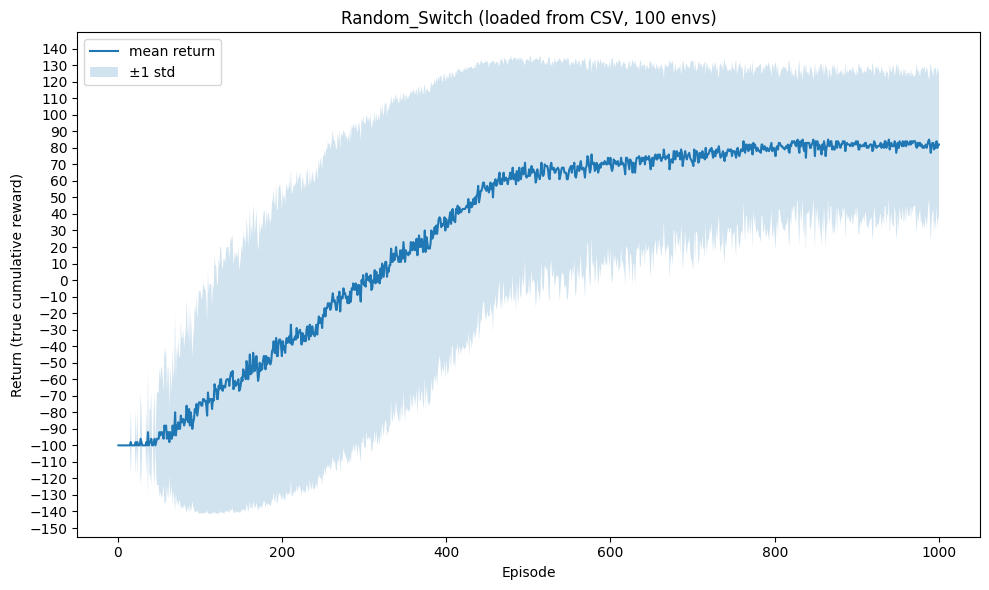

Final mean (ep 1000): 82.00 ± 45.56
Last-50 mean: 82.04 ± 44.13


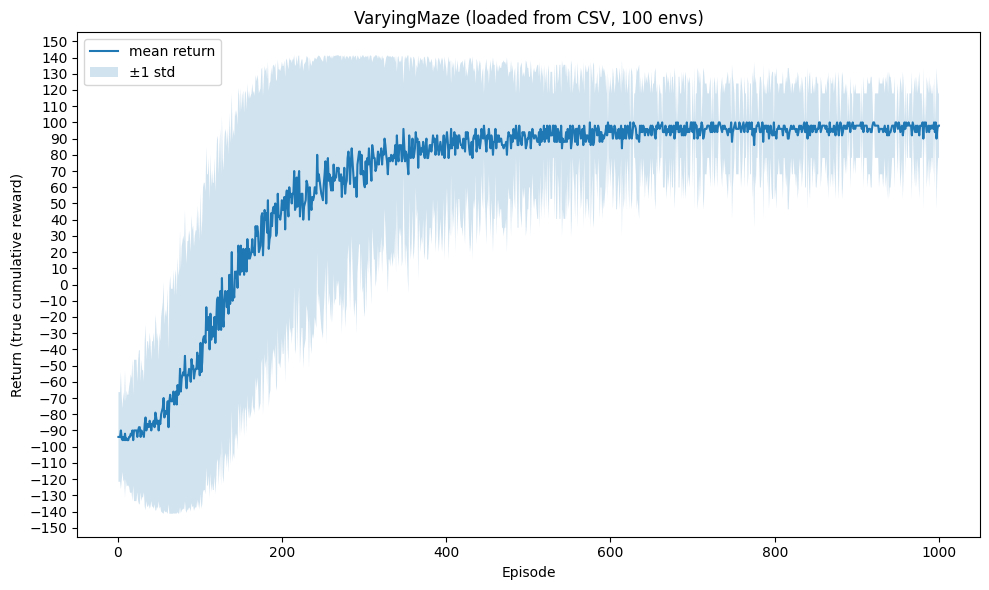

Final mean (ep 1000): 98.00 ± 19.90
Last-50 mean: 96.88 ± 21.19


In [16]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

def load_curve(csv_path):
    data = np.loadtxt(csv_path, delimiter=",", skiprows=1)
    ep     = data[:, 0]
    mean_r = data[:, 1]
    std_r  = data[:, 2]
    return ep, mean_r, std_r

def show_plot(csv_path, title):
    ep, mean_r, std_r = load_curve(csv_path)

    plt.figure(figsize=(10, 6))
    plt.plot(ep, mean_r, label="mean return")
    plt.fill_between(ep, mean_r - std_r, mean_r + std_r, alpha=0.2, label="±1 std")

    plt.xlabel("Episode")
    plt.ylabel("Return (true cumulative reward)")
    plt.title(title)

    # y-axis ticks every 10: -100, -90, ..., 0, 10, ..., 100
    plt.gca().yaxis.set_major_locator(MultipleLocator(10))

    plt.legend()
    plt.tight_layout()
    plt.show()

    print(f"Final mean (ep {int(ep[-1])}): {mean_r[-1]:.2f} ± {std_r[-1]:.2f}")
    print(f"Last-50 mean: {np.mean(mean_r[-50:]):.2f} ± {np.mean(std_r[-50:]):.2f}")

# Show Random_Switch
show_plot("random_switch_result_curve.csv", "Random_Switch (loaded from CSV, 100 envs)")

# Show VaryingMaze
show_plot("varying_maze_result_curve.csv", "VaryingMaze (loaded from CSV, 100 envs)")


## Demo RANDOM_SWITCH and VARYING_MAZE

Demo runtime: 4.70 seconds


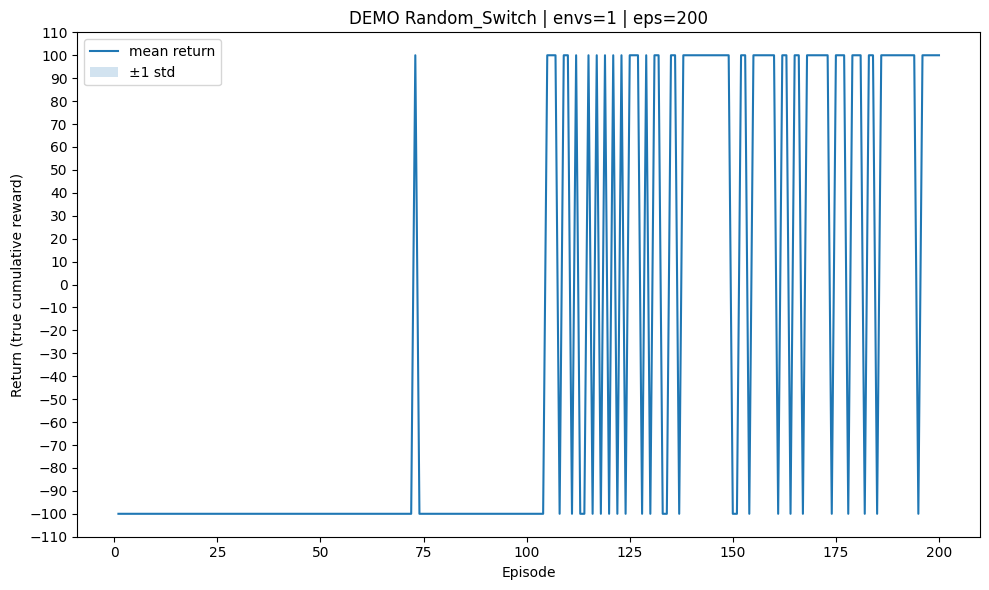

Final mean (ep 200): 100.00 ± 0.00
Last-50 mean: 60.00 ± 0.00
Demo runtime: 26.12 seconds


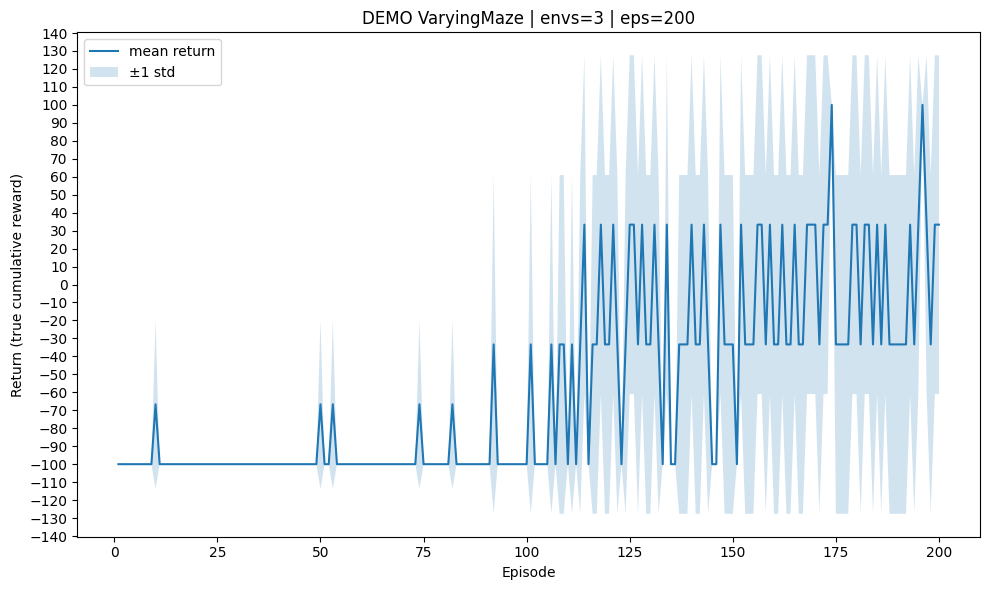

Final mean (ep 200): 33.33 ± 94.28
Last-50 mean: -0.00 ± 88.62


In [10]:
import time
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

def plot_curve_inline(mean_r, std_r, title):
    ep = np.arange(1, len(mean_r) + 1)

    plt.figure(figsize=(10, 6))
    plt.plot(ep, mean_r, label="mean return")
    plt.fill_between(ep, mean_r - std_r, mean_r + std_r, alpha=0.2, label="±1 std")

    plt.xlabel("Episode")
    plt.ylabel("Return (true cumulative reward)")
    plt.title(title)
    plt.gca().yaxis.set_major_locator(MultipleLocator(10))
    plt.legend()
    plt.tight_layout()
    plt.show()

    print(f"Final mean (ep {len(mean_r)}): {mean_r[-1]:.2f} ± {std_r[-1]:.2f}")
    print(f"Last-50 mean: {np.mean(mean_r[-50:]):.2f} ± {np.mean(std_r[-50:]):.2f}")

def run_fast_demo(cfg, title):
    t0 = time.perf_counter()
    mean_r, std_r = run_experiment(**cfg)
    t1 = time.perf_counter()

    print(f"Demo runtime: {(t1 - t0):.2f} seconds")
    plot_curve_inline(mean_r, std_r, title)
    return mean_r, std_r

# RANDOM_SWITCH quick demo
cfg_demo_random_switch = dict(
    env_name="random_switch",
    num_envs=1,          # <-- change to 1..5 for meeting
    episodes=200,        # <-- 100..400 is good for demo
    max_steps=250,       # <-- keep small for speed
    planning_steps=30,   # <-- lower for speed (still Dyna-Q)
    alpha=0.12,
    gamma=0.99,
    q_init=2.0,
    eps_start=1.0,
    eps_end=0.01,
    eps_decay=0.992,
    switch_safety=True,
    avoid_fatal=True,
    base_seed=1234
)

mean_demo_rs, std_demo_rs = run_fast_demo(
    cfg_demo_random_switch,
    title=f"DEMO Random_Switch | envs={cfg_demo_random_switch['num_envs']} | eps={cfg_demo_random_switch['episodes']}"
)

# VARYING_MAZE quick demo
cfg_demo_varying_maze = dict(
    env_name="varying_maze",
    num_envs=3,
    episodes=200,
    max_steps=250,
    planning_steps=30,
    alpha=0.12,
    gamma=0.99,
    q_init=2.0,
    eps_start=1.0,
    eps_end=0.02,
    eps_decay=0.993,
    switch_safety=False,   # required by run_experiment signature
    avoid_fatal=False,     # required by run_experiment signature
    base_seed=4321
)

mean_demo_vm, std_demo_vm = run_fast_demo(
    cfg_demo_varying_maze,
    title=f"DEMO VaryingMaze | envs={cfg_demo_varying_maze['num_envs']} | eps={cfg_demo_varying_maze['episodes']}"
)